In [54]:
import pandas as pd 

df=pd.read_csv("../data/SMSSpamCollection",sep="\t",header=None,names=["label","message"])

print(df['label'].value_counts(normalize=True)*100)

label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


In [55]:
df["message_length"]=df["message"].str.len()
print(df.groupby('label')['message_length'].describe())

        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4825.0   71.482487  58.440652   2.0   33.0   52.0   93.0  910.0
spam    747.0  138.670683  28.873603  13.0  133.0  149.0  157.0  223.0


In [ ]:
df.duplicated().sum()

In [57]:
print(df["label"].unique())
df[df.duplicated(keep=False)].sort_values("label").head(20)
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)
print("Duplicate rows:", df.duplicated().sum())

<StringArray>
['ham', 'spam']
Length: 2, dtype: str
Shape after removing duplicates: (5169, 3)
Duplicate rows: 0


In [58]:
print("Shape : ",df.shape)
print("Columns\n: ", df.columns.tolist())
print("\nmissing values:\n",df.isnull().sum())
print("\nDatatypes : ",df.dtypes)

Shape :  (5169, 3)
Columns
:  ['label', 'message', 'message_length']

missing values:
 label             0
message           0
message_length    0
dtype: int64

Datatypes :  label               str
message             str
message_length    int64
dtype: object


In [59]:
print(df.groupby("label")["message_length"].describe())
print(df.groupby("label")["message_length"].mean())
print(df.groupby("label")["message_length"].median())


        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4516.0   70.905890  56.715046   2.0   34.0   53.0   91.0  910.0
spam    653.0  137.704441  29.821348  13.0  132.0  148.0  157.0  223.0
label
ham      70.905890
spam    137.704441
Name: message_length, dtype: float64
label
ham      53.0
spam    148.0
Name: message_length, dtype: float64


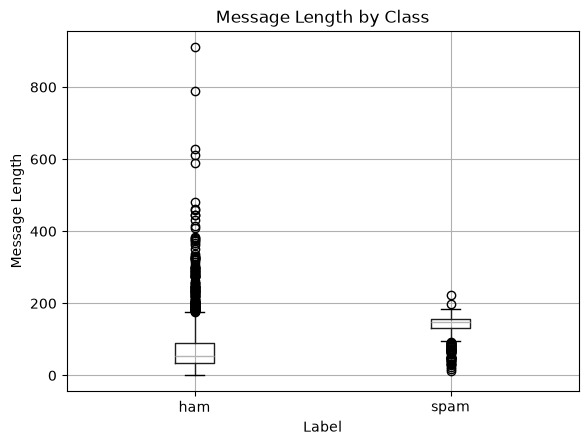

In [60]:

import matplotlib.pyplot as plt

df.boxplot(column="message_length", by="label")

plt.title("Message Length by Class")
plt.suptitle("")
plt.xlabel("Label")
plt.ylabel("Message Length")
plt.show()

In [62]:
# Convert labels into numerical values
df["label_num"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df.head()

,label,message,message_length,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",111,0
1,ham,Ok lar... Joking wif u oni...,29,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,1
3,ham,U dun say so early hor... U c already then say...,49,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,0


In [67]:
x=df['message']
y=df['label_num']

print(y.shape)

(5169,)


In [70]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

len(x_train)


4135